In [ ]:

# Bicanski 2026 - UCM: universal cognitive maps
# https://doi.org/10.1016/j.cub.2026.08.064
# correspondence: bicanski@cbs.mpg.de

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from pin import pin
from helper_fcts import Panel_Labels
from helper_fcts import get_index_in_interval
from helper_fcts import check_dataset_range
import numpy as np
from vna import calc_vectors_2d   # use for simplicity
from load_data_and_analyses import load_GCs
from load_data_and_analyses import load_oasis
from load_data_and_analyses import load_oasis_mapped
import pandas as pd

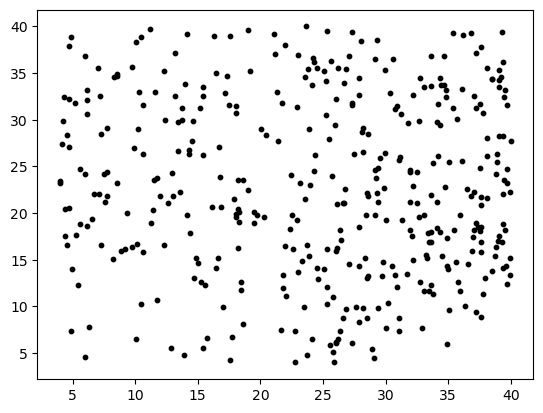

In [ ]:
##### load grid cells, vna, pin
GCs, res, N_GCs, N_mod, N_per_mod = load_GCs()
wts     = np.load("NAVwts/DCab2d.npz")
wts_mod = np.load("NAVwts/DCad2b_final.npz")
DCxpW   = wts_mod["DCxp_2_tGCs_WTS"]
DCxmW   = wts_mod["DCxm_2_tGCs_WTS"]
DCypW   = wts_mod["DCyp_2_tGCs_WTS"]
DCymW   = wts_mod["DCym_2_tGCs_WTS"]

# here for oasis, same procedure for birds

##### load oasis dataset
data, data_scaled, IDs, valence, arousal, aro_sub, val_sub = load_oasis()

##### load processed data and UCM
configname = 'BaseModel_Noise0'
Stims, PVs, PVs_xy, S1ind = load_oasis_mapped(configname)

dim1range, dim2range, prop, S1ind, S1coords, N_pts = check_dataset_range(data=data_scaled, dim1=val_sub, dim2=aro_sub, mapsize=res)

fig, ax3 = plt.subplots()

ax3.scatter(data_scaled[:,0],data_scaled[:,1], s=40, edgecolors='black', facecolors='black', marker='.')


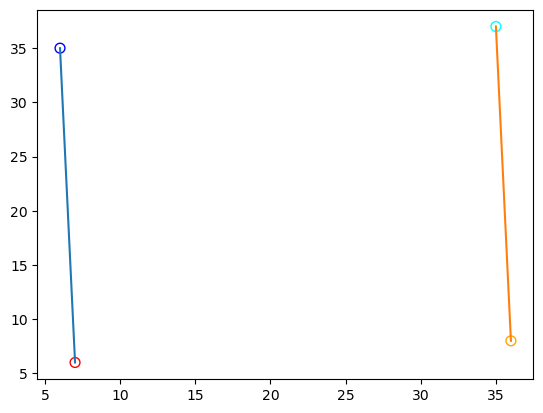

In [8]:
### Analogies

wts     = np.load("NAVwts/DCab2d.npz")
wts_mod = np.load("NAVwts/DCad2b_final.npz")
DCxpW   = wts_mod["DCxp_2_tGCs_WTS"]
DCxmW   = wts_mod["DCxm_2_tGCs_WTS"]
DCypW   = wts_mod["DCyp_2_tGCs_WTS"]
DCymW   = wts_mod["DCym_2_tGCs_WTS"]

# to test analogies quantitatively:
# - get two PVs on the "left"
# - calc distance with the vna
# - take another PV elsewhere on the map, i.e. on the right
# - use distance calculated before, with that PV, infer target PV

### one trial case for illustration

# left side computations, left right, up down, completely interchangable here
left_bottom_ind = get_index_in_interval(PVs_xy, dx=(6, 8), dy=(6, 8))  
left_top_ind    = get_index_in_interval(PVs_xy, dx=(6, 8), dy=(32, 36))
# Note, vectors need not be perfectly aligned if there is no mapped stimulus
# at D, in the exact relation of A to B. Hence the function 
# get_index_in_interval picks from a range.    

# make this interval larger for some variation
right_bottom_ind = get_index_in_interval(PVs_xy, dx=(32, 36), dy=(6, 8))  

xy_left_bottom  = PVs_xy[left_bottom_ind,:].astype(int)
xy_left_top     = PVs_xy[left_top_ind,:].astype(int)
xy_right_bottom = PVs_xy[right_bottom_ind,:].astype(int)

cGCs_left  = GCs[xy_left_bottom[1],xy_left_bottom[0],:]   # current PVs
tGCs_left  = GCs[xy_left_top[1],xy_left_top[0],:]      # target PVs
cGCs_right = GCs[xy_right_bottom[1],xy_right_bottom[0],:]

vector = calc_vectors_2d(cGCs_left, tGCs_left, GCs)

vector2 = np.array(xy_left_top-xy_left_bottom)

### inference time      
xy_tmp = pin(
    DCxpW=DCxpW, DCxmW=DCxmW, DCypW=DCypW, DCymW=DCymW,  
    res=res, vect=vector, xc=xy_right_bottom[0], yc=xy_right_bottom[1], GCs=GCs)

plt.scatter(xy_left_bottom[0], xy_left_bottom[1], s=50, facecolors='none', edgecolors='red')
plt.scatter(xy_left_top[0], xy_left_top[1], s=50, facecolors='none', edgecolors='blue')
plt.scatter(xy_right_bottom[0], xy_right_bottom[1], s=50, facecolors='none', edgecolors='orange')
plt.scatter( xy_tmp[0],  xy_tmp[1], s=50, facecolors='none', edgecolors='cyan')
plt.plot([xy_left_bottom[0], xy_left_bottom[0] + vector[0]], [xy_left_bottom[1], xy_left_bottom[1] + vector[1]])
plt.plot([xy_right_bottom[0], xy_right_bottom[0] + vector[0]], [xy_right_bottom[1], xy_right_bottom[1] + vector[1]])


27.474431626277134
on target
target on my left


Text(0, 0.5, 'dim2 [a.u.]')

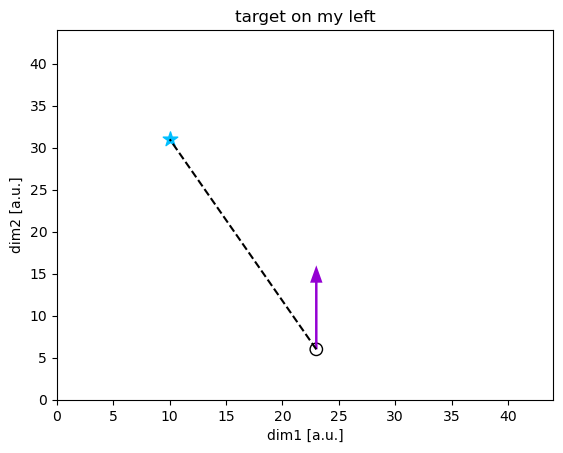

In [13]:
### Egocentric perspective taking

wts     = np.load("NAVwts/DCab2d.npz")
wts_mod = np.load("NAVwts/DCad2b_final.npz")
DCxpW   = wts_mod["DCxp_2_tGCs_WTS"]
DCxmW   = wts_mod["DCxm_2_tGCs_WTS"]
DCypW   = wts_mod["DCyp_2_tGCs_WTS"]
DCymW   = wts_mod["DCym_2_tGCs_WTS"]

# to test perspective computations quantitatively:
# - current agent location on the map is Axy, with heading theta
# - make a unit heading vector, that we assume is given by the HD system
# - The test stimulus location is Sxy
# - VNA gives us the vector Axy to Sxy
# - compare to heading vector. 
#      - How? Could extrapolate heading vector to same distance as Sxy is from you, see where it lands via PIN
#      - or simply calculate angle between vectors - a heuristic. 

# one trial case

# get a starting stimulus in some interval
Self_stim_ind  = get_index_in_interval(PVs_xy, dx=(20, 24), dy=(6, 8))  
Self_stim_xy   = PVs_xy[Self_stim_ind,:].astype(int)
Heading_end_xy = [Self_stim_xy[0], Self_stim_xy[1]+10]

# get goal stimuli
Goal_stim_left_ind  = get_index_in_interval(PVs_xy, dx=(6, 12), dy=(30, 40))  
Goal_stim_right_ind = get_index_in_interval(PVs_xy, dx=(28, 34), dy=(30, 40))
Goal_stim_left_xy   = PVs_xy[Goal_stim_left_ind,:].astype(int)
Goal_stim_right_xy  = PVs_xy[Goal_stim_right_ind,:].astype(int)

#flip coin for left or right test
if np.random.rand() > 0.5:
    Goal_stim_xy = Goal_stim_left_xy
else:
    Goal_stim_xy = Goal_stim_right_xy

cGCs      = GCs[Self_stim_xy[1],Self_stim_xy[0],:]      # current PVs
tGCs_head = GCs[Heading_end_xy[1],Heading_end_xy[0],:]  # target PVs
tGCs_goal = GCs[Goal_stim_xy[1],Goal_stim_xy[0],:]

hx_diff, hy_diff = calc_vectors_2d(cGCs,tGCs_head,GCs)
hv = np.array([hx_diff, hy_diff]) # heading_vector

gx_diff, gy_diff = calc_vectors_2d(cGCs,tGCs_goal,GCs)
gv = np.array([gx_diff, gy_diff]) # goal_vector
angle = np.degrees(np.arctan2(np.cross(hv, gv), np.dot(hv, gv)))
# positve is CCW, negative is CW

print(angle)

if angle > -2 or angle < 2:
    print("on target")
    mystr = "on target"

if angle < 2:
    print("target on my right")
    mystr = "target on my right"

if angle > -2:
    print("target on my left")
    mystr = "target on my left"

# visualize

x = [Self_stim_xy[0], Goal_stim_xy[0]]
y = [Self_stim_xy[1], Goal_stim_xy[1]]

fig, ax = plt.subplots()
ax.scatter(Self_stim_xy[0], Self_stim_xy[1], s=80, facecolors='none', edgecolors='black')
ax.quiver(
    Self_stim_xy[0], Self_stim_xy[1], hx_diff, hy_diff,
    angles='xy', scale_units='xy', scale=1,
    color='darkviolet',
    width=0.005,          # optional, thickness of arrows
    headwidth=5,          # size of arrowhead (can tune relative to length)
    headlength=7,
    headaxislength=7)
ax.scatter(Goal_stim_xy[0], Goal_stim_xy[1], s=120, marker='*', facecolors='deepskyblue', edgecolors='deepskyblue')
ax.plot(x, y, '--', color='black')
ax.set_xlim(0, 44)
ax.set_ylim(0, 44)
ax.set_title(mystr)
ax.set_xlabel('dim1 [a.u.]')
ax.set_ylabel('dim2 [a.u.]')


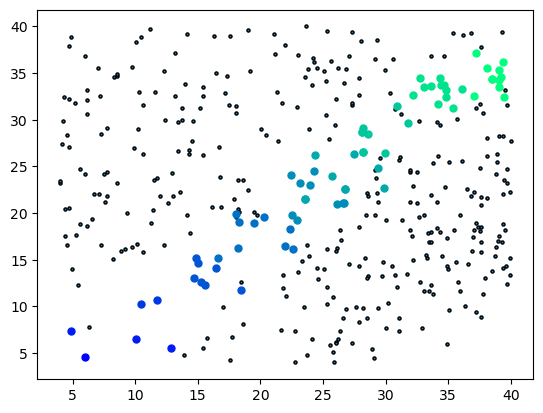

In [18]:
### Subspace construction

# find start of diagonal
start_ind  = get_index_in_interval(PVs_xy, dx=(2, 8), dy=(2, 8))  

# find end of diagonal
end_ind  = get_index_in_interval(PVs_xy, dx=(36, 42), dy=(36, 42))

# get xy
start_xy = PVs_xy[start_ind,:].astype(int)
end_xy   = PVs_xy[end_ind,:].astype(int)

# get PVs
sGCs = GCs[start_xy[1],start_xy[0],:]   # current PVs
tGCs = GCs[end_xy[1],end_xy[0],:]      # target PVs

# vector start to end
sub_x_diff, sub_y_diff = calc_vectors_2d(sGCs,tGCs,GCs)
sub_vec = np.array([sub_x_diff, sub_y_diff]) # heading_vector

# now in n increments scale the vector, find all stimuli in small radius

### oasis data
fig, ax1 = plt.subplots()
ax1.scatter(data_scaled[:,0], data_scaled[:,1], s=20, edgecolors='black', marker='.')

N   = 10
rad = 3

cmap = plt.cm.winter
colors = cmap(np.linspace(0, 1, N))

all_inds = np.array([], dtype=int)
all_colors = []
ind_list = []

for i in range(N):
    
    scaled_x   = np.round(i/N * sub_vec[0]) # her both x and y scaled equally, but could change that
    scaled_y   = np.round(i/N * sub_vec[1])
    scaled_vec = np.array([scaled_x, scaled_y])
    
    Axs = start_xy[0]
    Ays = start_xy[1]
    
    xy = pin(
        DCxpW=DCxpW, DCxmW=DCxmW, DCypW=DCypW, DCymW=DCymW,  
        res=res, vect=scaled_vec, xc=Axs, yc=Ays, GCs=GCs)

    # now we have xy and if we want a PV, but we don't know if there is a stimulus mapped
    # so find all the ones with coords nearby

    squared_dist = (PVs_xy[:, 0] - xy[0])**2 + (PVs_xy[:, 1] - xy[1])**2
    inds         = np.where(squared_dist <= rad**2)[0]

    color = colors[i]
    all_colors.append(color)
    ind_list.append(inds)

    ax1.scatter(data_scaled[inds, 0], data_scaled[inds, 1], s=25, color=colors[i])


